# Radius Summary Overview

This notebook provides an overview of the experiment results from the radius_summary.json file.

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## Load the JSON File

In [3]:
# Load the JSON file
json_path = r'e:\data\radius_search_plus\20260511-080325Z\radius_5km\radius_summary.json'
with open(json_path, 'r') as f:
    data = json.load(f)

print(f"File loaded: {json_path}")
print(f"Keys in data: {list(data.keys())}")

File loaded: e:\data\radius_search_plus\20260511-080325Z\radius_5km\radius_summary.json
Keys in data: ['radius_km', 'completed', 'mean_best_val_auc', 'mean_test_auc', 'mean_test_loss', 'num_trained_folds', 'num_skipped_folds', 'skipped_folds', 'fold_results']


## Summary Statistics

In [4]:
# Display top-level summary metrics
summary = {
    'Radius (km)': data['radius_km'],
    'Completed': data['completed'],
    'Trained Folds': data['num_trained_folds'],
    'Skipped Folds': data['num_skipped_folds'],
    'Mean Best Validation AUC': f"{data['mean_best_val_auc']:.4f}",
    'Mean Test AUC': f"{data['mean_test_auc']:.4f}",
    'Mean Test Loss': f"{data['mean_test_loss']:.4f}"
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
display(summary_df)

,Metric,Value
0,Radius (km),5.0
1,Completed,True
2,Trained Folds,5
3,Skipped Folds,0
4,Mean Best Validation AUC,0.5110
5,Mean Test AUC,0.4585
6,Mean Test Loss,3.1872


## Fold Results Overview

In [5]:
# Extract fold results
fold_results = []
for fold in data['fold_results']:
    fold_results.append({
        'Fold ID': fold['fold_id'],
        'Best Val AUC': f"{fold['best_val_auc']:.4f}",
        'Best Val Loss': f"{fold['best_val_loss']:.4f}",
        'Test Loss': f"{fold['test_metrics']['loss']:.4f}",
        'Test Accuracy': f"{fold['test_metrics']['acc']:.4f}",
        'Test AUC': f"{fold['test_metrics']['auc']:.4f}",
        'Test Precision': f"{fold['test_metrics']['precision']:.4f}",
        'Test Recall': f"{fold['test_metrics']['recall']:.4f}"
    })

fold_df = pd.DataFrame(fold_results)
display(fold_df)

,Fold ID,Best Val AUC,Best Val Loss,Test Loss,Test Accuracy,Test AUC,Test Precision,Test Recall
0,0,0.5001,3.4728,3.0005,0.6829,0.7034,0.0000,0.0000
1,1,0.5379,0.6401,0.9965,0.3605,0.4494,0.3603,0.9998
2,2,0.3847,1.6917,0.8476,0.1350,0.5300,0.1350,1.0000
3,3,0.6330,0.6388,0.7630,0.4190,0.4546,0.2203,0.5862
4,4,0.4992,26.5960,10.3281,0.3216,0.1554,0.0000,0.0000


## Test Metrics Comparison Across Folds

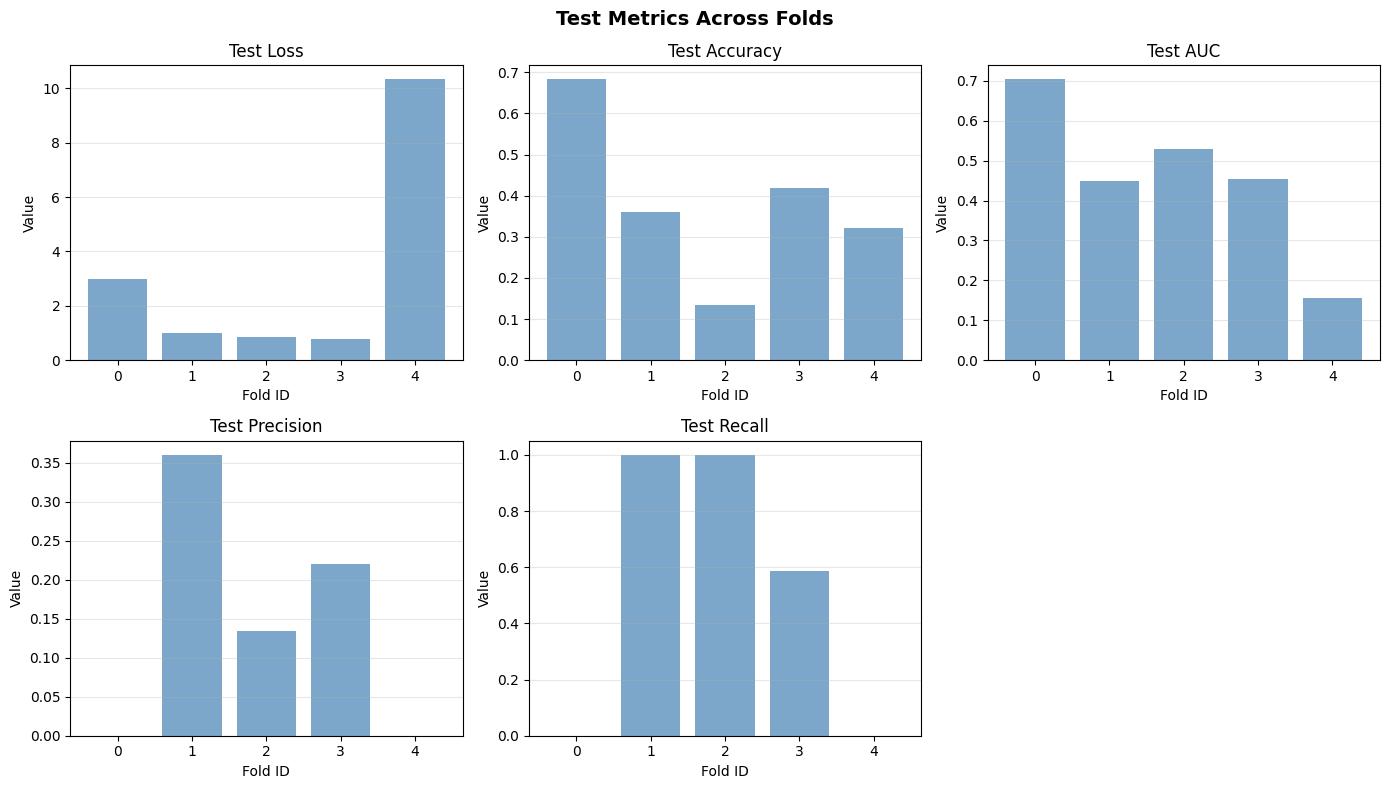


Metrics Statistics:
        Fold ID  Test Loss  Test Accuracy  Test AUC  Test Precision  \
count  5.000000   5.000000       5.000000  5.000000        5.000000   
mean   2.000000   3.187161       0.383794  0.458544        0.143119   
std    1.581139   4.098038       0.198160  0.198147        0.153435   
min    0.000000   0.763041       0.134964  0.155381        0.000000   
25%    1.000000   0.847639       0.321551  0.449413        0.000000   
50%    2.000000   0.996546       0.360466  0.454571        0.134964   
75%    3.000000   3.000525       0.419043  0.529988        0.220301   
max    4.000000  10.328052       0.682946  0.703365        0.360328   

       Test Recall  
count     5.000000  
mean      0.517200  
std       0.501426  
min       0.000000  
25%       0.000000  
50%       0.586243  
75%       0.999755  
max       1.000000  


In [6]:
# Extract numeric test metrics for plotting
fold_metrics = []
for fold in data['fold_results']:
    fold_metrics.append({
        'Fold ID': fold['fold_id'],
        'Test Loss': fold['test_metrics']['loss'],
        'Test Accuracy': fold['test_metrics']['acc'],
        'Test AUC': fold['test_metrics']['auc'],
        'Test Precision': fold['test_metrics']['precision'],
        'Test Recall': fold['test_metrics']['recall']
    })

metrics_df = pd.DataFrame(fold_metrics)

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Test Metrics Across Folds', fontsize=14, fontweight='bold')

metrics_to_plot = ['Test Loss', 'Test Accuracy', 'Test AUC', 'Test Precision', 'Test Recall']
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    axes[idx].bar(metrics_df['Fold ID'], metrics_df[metric], color='steelblue', alpha=0.7)
    axes[idx].set_title(metric)
    axes[idx].set_xlabel('Fold ID')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

# Remove the extra subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

print("\nMetrics Statistics:")
print(metrics_df.describe())

## Training History for First Fold

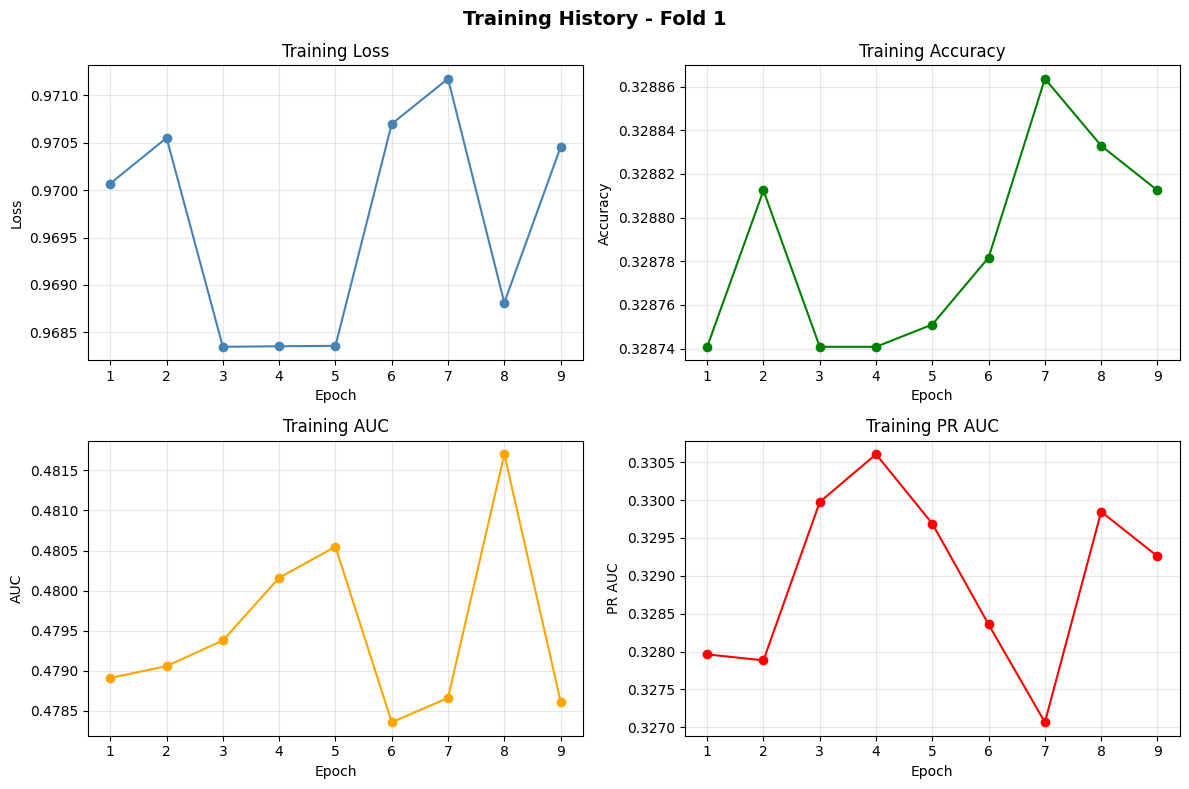

In [7]:
# Plot training history from the first fold
first_fold = data['fold_results'][1]
history = first_fold['history']

epochs = list(range(1, len(history['loss']) + 1))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Training History - Fold {first_fold['fold_id']}", fontsize=14, fontweight='bold')

# Loss
axes[0, 0].plot(epochs, history['loss'], 'o-', label='Training Loss', color='steelblue')
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, history['acc'], 'o-', label='Training Accuracy', color='green')
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].grid(alpha=0.3)

# AUC
axes[1, 0].plot(epochs, history['auc'], 'o-', label='Training AUC', color='orange')
axes[1, 0].set_title('Training AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].grid(alpha=0.3)

# PR AUC
if 'pr_auc' in history:
    axes[1, 1].plot(epochs, history['pr_auc'], 'o-', label='Training PR AUC', color='red')
    axes[1, 1].set_title('Training PR AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('PR AUC')
else:
    axes[1, 1].text(0.5, 0.5, 'PR AUC data not available', ha='center', va='center')

axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Validation Metrics Comparison

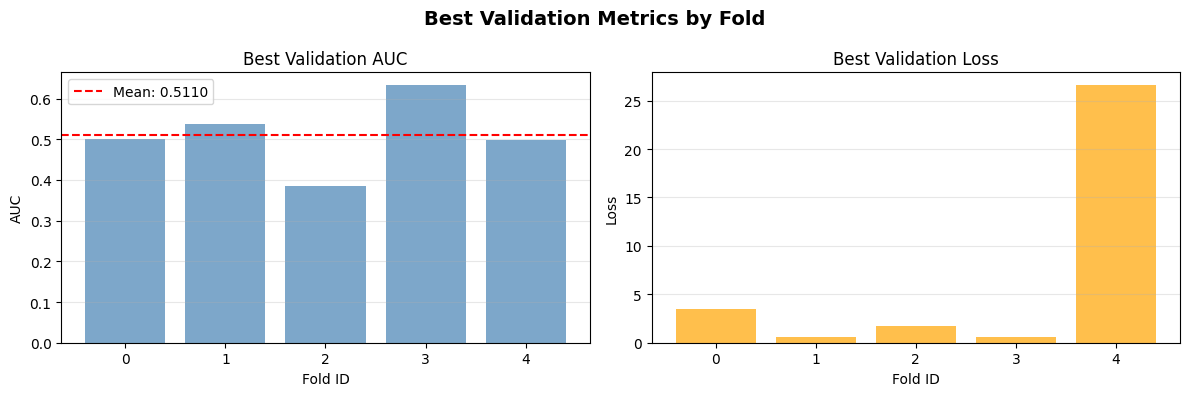


Validation Metrics Statistics:
        Fold ID  Best Val AUC  Best Val Loss
count  5.000000      5.000000       5.000000
mean   2.000000      0.510968       6.607879
std    1.581139      0.089172      11.233490
min    0.000000      0.384747       0.638837
25%    1.000000      0.499173       0.640058
50%    2.000000      0.500061       1.691744
75%    3.000000      0.537851       3.472791
max    4.000000      0.633008      26.595966


In [8]:
# Compare best validation metrics across folds
val_metrics = []
for fold in data['fold_results']:
    val_metrics.append({
        'Fold ID': fold['fold_id'],
        'Best Val AUC': fold['best_val_auc'],
        'Best Val Loss': fold['best_val_loss']
    })

val_df = pd.DataFrame(val_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Best Validation Metrics by Fold', fontsize=14, fontweight='bold')

axes[0].bar(val_df['Fold ID'], val_df['Best Val AUC'], color='steelblue', alpha=0.7)
axes[0].axhline(y=data['mean_best_val_auc'], color='red', linestyle='--', label=f"Mean: {data['mean_best_val_auc']:.4f}")
axes[0].set_title('Best Validation AUC')
axes[0].set_xlabel('Fold ID')
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(val_df['Fold ID'], val_df['Best Val Loss'], color='orange', alpha=0.7)
axes[1].set_title('Best Validation Loss')
axes[1].set_xlabel('Fold ID')
axes[1].set_ylabel('Loss')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nValidation Metrics Statistics:")
print(val_df.describe())

## File Structure Details

In [9]:
# Show paths and configuration details
print("Configuration:")
print(f"  Radius: {data['radius_km']} km")
print(f"  Freeze Backbone: {data['fold_results'][0]['freeze_backbone']}")
print(f"\nFirst Fold Paths:")
first_fold = data['fold_results'][0]
print(f"  Split JSON: {first_fold['split_json']}")
print(f"  Manifest: {first_fold['manifest_path']}")
print(f"  Training Output: {first_fold['train_output_dir']}")
print(f"\nSkipped Folds: {data['skipped_folds'] if data['skipped_folds'] else 'None'}")

Configuration:
  Radius: 5.0 km
  Freeze Backbone: False

First Fold Paths:
  Split JSON: /mnt/e/data/radius_search_plus/_cache/radius_5km/norwegian_only/fold_0_test_0/split.json
  Manifest: /mnt/e/data/radius_search_plus/_cache/radius_5km/norwegian_only/fold_0_test_0/manifest.csv
  Training Output: /mnt/e/data/radius_search_plus/20260511-080325Z/radius_5km/norwegian_only/fold_0_test_0/training

Skipped Folds: None


## Pos Rate Overview Across Radii and Folds

Loaded: e:\\data\\radius_search_plus\\20260511-080325Z\\radius_search_summary.json
Rows in fold/radius pos-rate table: 30


,radius_km,fold_id,status,train_pos_rate_percent,val_pos_rate_percent,test_pos_rate_percent
0,1.0,0,skipped,0.648527,0.000000,0.000000
1,1.0,1,skipped,1.380842,0.052369,0.000000
2,1.0,2,trained,1.374211,0.127412,0.052369
3,1.0,3,trained,0.034814,8.792561,0.127412
4,1.0,4,skipped,0.057686,0.000000,8.792561
5,2.0,0,skipped,2.326266,1.502217,0.000000
6,2.0,1,trained,3.408602,1.151473,1.502217
7,2.0,2,trained,3.558415,1.377260,1.151473
8,2.0,3,trained,1.054611,18.111582,1.377260
9,2.0,4,skipped,1.259145,0.000000,18.111582


\nTest split pos_rate_percent pivot:


fold_id,0,1,2,3,4
radius_km,,,,,
1.0,0.000000,0.000000,0.052369,0.127412,8.792561
2.0,0.000000,1.502217,1.151473,1.377260,18.111582
3.0,0.056511,3.011052,4.252724,3.304615,43.169698
4.0,2.697638,8.139766,8.545043,7.968289,60.460823
5.0,31.705431,36.028941,13.496443,23.344659,67.776562
6.0,35.503539,45.708424,17.820695,31.602152,73.882128


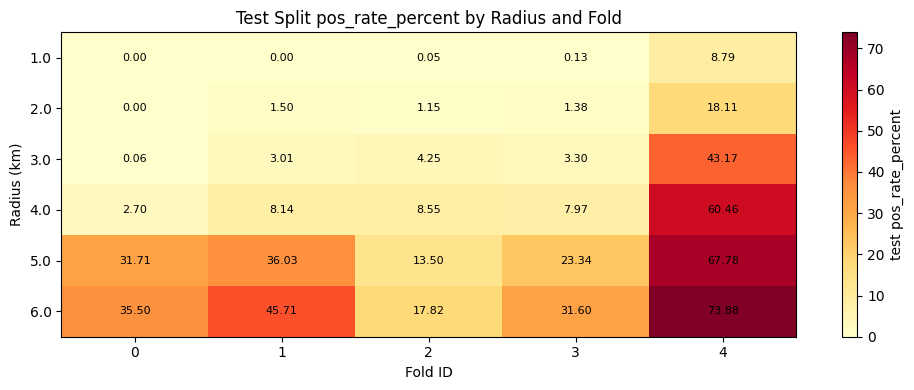

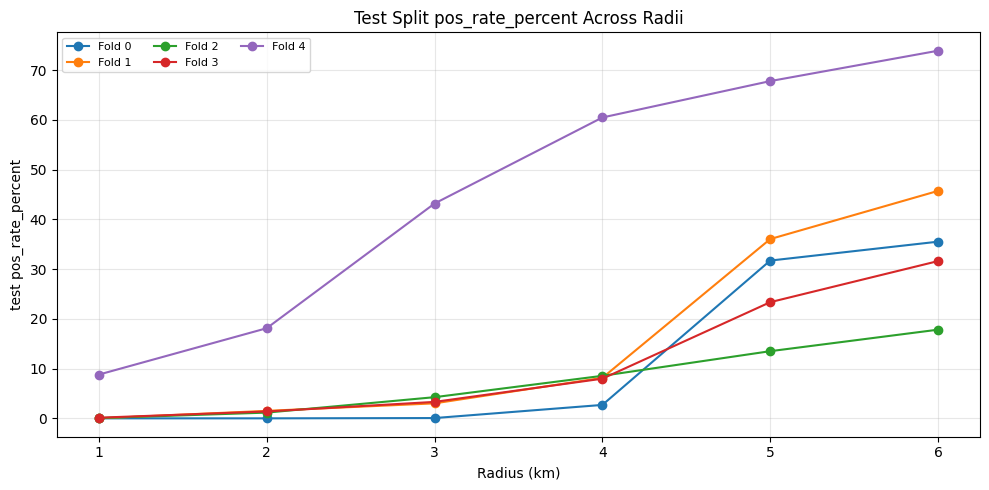

In [12]:
# Load radius search summary and extract fold-level positive label rates across radii
radius_search_path = r"e:\\data\\radius_search_plus\\20260511-080325Z\\radius_search_summary.json"

with open(radius_search_path, "r") as f:
    radius_search_data = json.load(f)

pos_rate_rows = []

for radius_result in radius_search_data.get("radius_results", []):
    radius_km = radius_result.get("radius_km")

    for fold in radius_result.get("fold_results", []):
        label_overview = fold.get("pretrain_label_overview", {})
        pos_rate_rows.append({
            "radius_km": radius_km,
            "fold_id": fold.get("fold_id"),
            "status": "trained",
            "train_pos_rate_percent": (label_overview.get("train") or {}).get("pos_rate_percent"),
            "val_pos_rate_percent": (label_overview.get("val") or {}).get("pos_rate_percent"),
            "test_pos_rate_percent": (label_overview.get("test") or {}).get("pos_rate_percent"),
        })

    for skipped in radius_result.get("skipped_folds", []):
        label_overview = skipped.get("label_overview_pretrain", {})
        pos_rate_rows.append({
            "radius_km": radius_km,
            "fold_id": skipped.get("fold_id"),
            "status": "skipped",
            "train_pos_rate_percent": (label_overview.get("train") or {}).get("pos_rate_percent"),
            "val_pos_rate_percent": (label_overview.get("val") or {}).get("pos_rate_percent"),
            "test_pos_rate_percent": (label_overview.get("test") or {}).get("pos_rate_percent"),
        })

pos_rate_df = pd.DataFrame(pos_rate_rows).sort_values(["radius_km", "fold_id"]).reset_index(drop=True)

print(f"Loaded: {radius_search_path}")
print(f"Rows in fold/radius pos-rate table: {len(pos_rate_df)}")
display(pos_rate_df)

# Pivot table for test split pos rate (%) by radius and fold
test_pos_pivot = pos_rate_df.pivot_table(
    index="radius_km",
    columns="fold_id",
    values="test_pos_rate_percent",
    aggfunc="first",
)

print("\\nTest split pos_rate_percent pivot:")
display(test_pos_pivot)

# Heatmap-style plot using matplotlib
fig, ax = plt.subplots(figsize=(10, 4))
heatmap_data = test_pos_pivot.values
im = ax.imshow(heatmap_data, aspect="auto", cmap="YlOrRd")

ax.set_title("Test Split pos_rate_percent by Radius and Fold")
ax.set_xlabel("Fold ID")
ax.set_ylabel("Radius (km)")
ax.set_xticks(np.arange(len(test_pos_pivot.columns)))
ax.set_xticklabels(test_pos_pivot.columns)
ax.set_yticks(np.arange(len(test_pos_pivot.index)))
ax.set_yticklabels(test_pos_pivot.index)

# Annotate values in each cell
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("test pos_rate_percent")
plt.tight_layout()
plt.show()

# Per-fold trend lines across radii
fig, ax = plt.subplots(figsize=(10, 5))
for fold_id in sorted(test_pos_pivot.columns):
    ax.plot(
        test_pos_pivot.index,
        test_pos_pivot[fold_id],
        marker="o",
        label=f"Fold {fold_id}",
    )

ax.set_title("Test Split pos_rate_percent Across Radii")
ax.set_xlabel("Radius (km)")
ax.set_ylabel("test pos_rate_percent")
ax.grid(alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## Final Summary

In [11]:
# Create a comprehensive summary
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"\nExperiment Configuration:")
print(f"  Radius: {data['radius_km']} km")
print(f"  Folds Trained: {data['num_trained_folds']}")
print(f"  Folds Skipped: {data['num_skipped_folds']}")
print(f"  Status: {'✓ Completed' if data['completed'] else '✗ Incomplete'}")

print(f"\nAggregated Results:")
print(f"  Mean Best Validation AUC: {data['mean_best_val_auc']:.4f}")
print(f"  Mean Test AUC: {data['mean_test_auc']:.4f}")
print(f"  Mean Test Loss: {data['mean_test_loss']:.4f}")

# Calculate additional stats
test_aucs = [fold['test_metrics']['auc'] for fold in data['fold_results']]
test_accs = [fold['test_metrics']['acc'] for fold in data['fold_results']]

print(f"\nTest Performance Statistics:")
print(f"  Test AUC - Min: {min(test_aucs):.4f}, Max: {max(test_aucs):.4f}, Std: {np.std(test_aucs):.4f}")
print(f"  Test Accuracy - Min: {min(test_accs):.4f}, Max: {max(test_accs):.4f}, Std: {np.std(test_accs):.4f}")

print("\n" + "=" * 60)

EXPERIMENT SUMMARY

Experiment Configuration:
  Radius: 5.0 km
  Folds Trained: 5
  Folds Skipped: 0
  Status: ✓ Completed

Aggregated Results:
  Mean Best Validation AUC: 0.5110
  Mean Test AUC: 0.4585
  Mean Test Loss: 3.1872

Test Performance Statistics:
  Test AUC - Min: 0.1554, Max: 0.7034, Std: 0.1772
  Test Accuracy - Min: 0.1350, Max: 0.6829, Std: 0.1772

